# Análise de Gargalos Logísticos com Descoberta de Subgrupos
## Etapas 3 e 4: Aplicação do pysubgroup e Análise dos Resultados

**Disciplina:** Aprendizado Descritivo (DCC831)  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist   
**Alunos:** Guilherme Salles, Arthur Pereira, Lívia Castro, Davi Sakamoto

---

### Objetivo desta etapa
- Aplicar descoberta de subgrupos supervisionada usando "pysubgroup"
- Usar como alvo a variável "atrasado" (binária)
- Explorar e interpretar os subgrupos encontrados
- Avaliar a qualidade dos padrões com métricas adequadas

## 1. Carregamento do dataset pré-processado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pysubgroup as ps
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/olist_preprocessado.csv', dtype=str)

# Variável-alvo precisa ser numérica
df['atrasado'] = df['atrasado'].astype(int)

print(f'Shape: {df.shape}')
print(f'Taxa de atraso geral: {df["atrasado"].mean():.1%}')
df.head(3)

Shape: (96470, 10)
Taxa de atraso geral: 6.8%


,atrasado,customer_state,seller_state,interestadual,peso_cat,volume_cat,product_category_name,frete_cat,preco_cat,mes_compra
0,0,SP,SP,intraestadual,peso_medio_baixo,volume_baixo,utilidades_domesticas,frete_baixo,preco_baixo,10
1,0,BA,SP,interestadual,peso_medio_baixo,volume_medio_baixo,perfumaria,frete_alto,preco_medio_alto,7
2,0,GO,SP,interestadual,peso_medio_baixo,volume_medio_alto,automotivo,frete_medio_alto,preco_alto,8


## 2. Configuração do pysubgroup

### Conceitos principais
- **Target**: variável que queremos explicar —> atrasado (binária)
- **Qualidade**: medida que avalia o quão interessante é um subgrupo. Usaremos WRAcc (Weighted Relative Accuracy), padrão para targets binários
- **Algoritmo de busca**: BeamSearch —> heurística eficiente que explora combinações de atributos sem precisar testar todas as possibilidades
- **Depth**: profundidade máxima das descrições (número de condições por subgrupo)

In [2]:
# Definir target: variável binária 'atrasado'
target = ps.BinaryTarget('atrasado', True)

# Definir o espaço de busca: todos os atributos exceto o target
feature_cols = [c for c in df.columns if c != 'atrasado']
search_space = ps.create_selectors(df, ignore=['atrasado'])

print(f'Features usadas na busca: {feature_cols}')
print(f'Total de seletores gerados: {len(search_space)}')

Features usadas na busca: ['customer_state', 'seller_state', 'interestadual', 'peso_cat', 'volume_cat', 'product_category_name', 'frete_cat', 'preco_cat', 'mes_compra']
Total de seletores gerados: 153


## 3. Execução da busca de subgrupos

Rodamos o BeamSearch com:
- `depth=3`: subgrupos com até 3 condições combinadas
- `beam_width=20`: mantém os 20 melhores candidatos a cada nível
- `result_set_size=20`: retorna os 20 melhores subgrupos finais

In [13]:
# Configurar e executar o BeamSearch
task = ps.SubgroupDiscoveryTask(
    df,
    target,
    search_space,
    result_set_size=20,
    depth=3,
    qf=ps.WRAccQF()       # métrica de qualidade: WRAcc
)

algorithm = ps.BeamSearch(beam_width=20)

result = algorithm.execute(task)
print('Busca concluída!')

Busca concluída!


## 4. Visualização dos resultados brutos

In [4]:
# Converter resultado para DataFrame
resultados = result.to_dataframe()

# Renomear colunas para melhor legibilidade
resultados = resultados.rename(columns={
    'quality':             'wracc',
    'subgroup':            'descricao',
    'size_sg':             'tamanho_sg',
    'size_dataset':        'tamanho_total',
    'positives_sg':        'atrasados_sg',
    'positives_dataset':   'atrasados_total',
    'target_share_sg':     'taxa_atraso_sg',
    'target_share_dataset':'taxa_atraso_geral'
})

# Calcular cobertura e lift
resultados['cobertura'] = resultados['tamanho_sg'] / resultados['tamanho_total']
resultados['lift']      = resultados['taxa_atraso_sg'] / resultados['taxa_atraso_geral']

# Exibir tabela principal
cols_exibir = ['descricao', 'wracc', 'tamanho_sg', 'taxa_atraso_sg',
               'taxa_atraso_geral', 'cobertura', 'lift']
pd.set_option('display.max_colwidth', 80)
resultados[cols_exibir].round(4)

,descricao,wracc,tamanho_sg,taxa_atraso_sg,taxa_atraso_geral,cobertura,lift
0,interestadual=='interestadual' AND seller_state=='SP',0.0107,37680,0.0952,0.0677,0.3906,1.4055
1,mes_compra=='3',0.0083,9549,0.1512,0.0677,0.0990,2.2327
2,interestadual=='interestadual' AND mes_compra=='3',0.0082,6196,0.1951,0.0677,0.0642,2.8809
3,interestadual=='interestadual',0.0082,61769,0.0805,0.0677,0.6403,1.1882
4,customer_state=='RJ' AND interestadual=='interestadual',0.0070,11394,0.1273,0.0677,0.1181,1.8789
5,mes_compra=='3' AND seller_state=='SP',0.0070,6792,0.1670,0.0677,0.0704,2.4651
6,interestadual=='interestadual' AND mes_compra=='3' AND seller_state=='SP',0.0068,3801,0.2410,0.0677,0.0394,3.5580
7,customer_state=='RJ',0.0068,12350,0.1211,0.0677,0.1280,1.7873
8,customer_state=='RJ' AND seller_state=='SP',0.0062,8158,0.1412,0.0677,0.0846,2.0849
9,customer_state=='RJ' AND interestadual=='interestadual' AND seller_state=='SP',0.0062,8158,0.1412,0.0677,0.0846,2.0849


## 5. Análise dos resultados

### 5.1 Gráfico: WRAcc vs Taxa de Atraso no Subgrupo

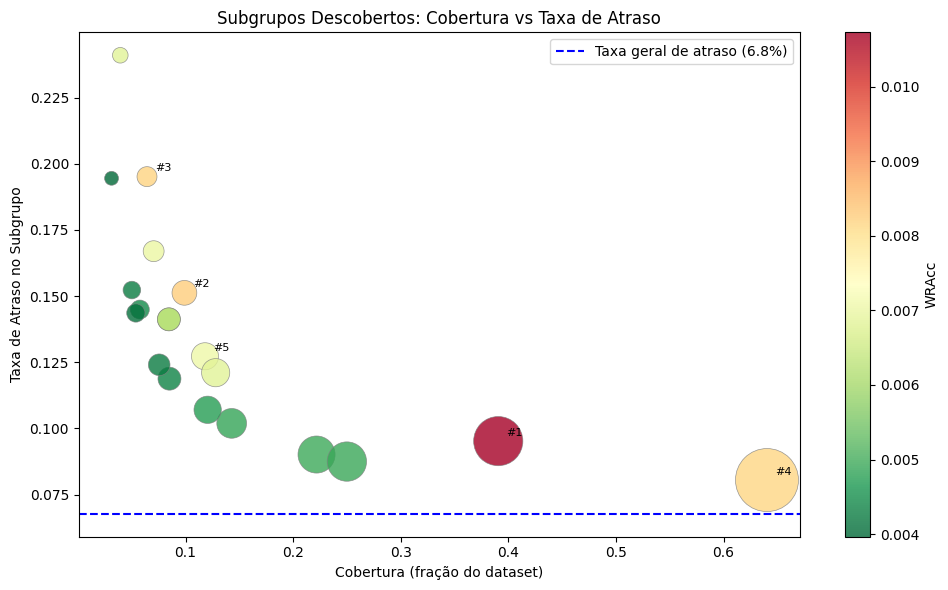

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    resultados['cobertura'],
    resultados['taxa_atraso_sg'],
    c=resultados['wracc'],
    cmap='RdYlGn_r',
    s=resultados['tamanho_sg'] / 30,
    alpha=0.8,
    edgecolors='gray',
    linewidth=0.5
)

# Linha de referência: taxa geral de atraso
taxa_geral = resultados['taxa_atraso_geral'].iloc[0]
ax.axhline(taxa_geral, color='blue', linestyle='--', linewidth=1.5,
           label=f'Taxa geral de atraso ({taxa_geral:.1%})')

# Anotar os 5 melhores
for i, row in resultados.head(5).iterrows():
    ax.annotate(f'#{i+1}', (row['cobertura'], row['taxa_atraso_sg']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

plt.colorbar(scatter, label='WRAcc')
ax.set_xlabel('Cobertura (fração do dataset)')
ax.set_ylabel('Taxa de Atraso no Subgrupo')
ax.set_title('Subgrupos Descobertos: Cobertura vs Taxa de Atraso')
ax.legend()
plt.tight_layout()
plt.savefig('./data/scatter_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Gráfico: Top 10 Subgrupos por WRAcc

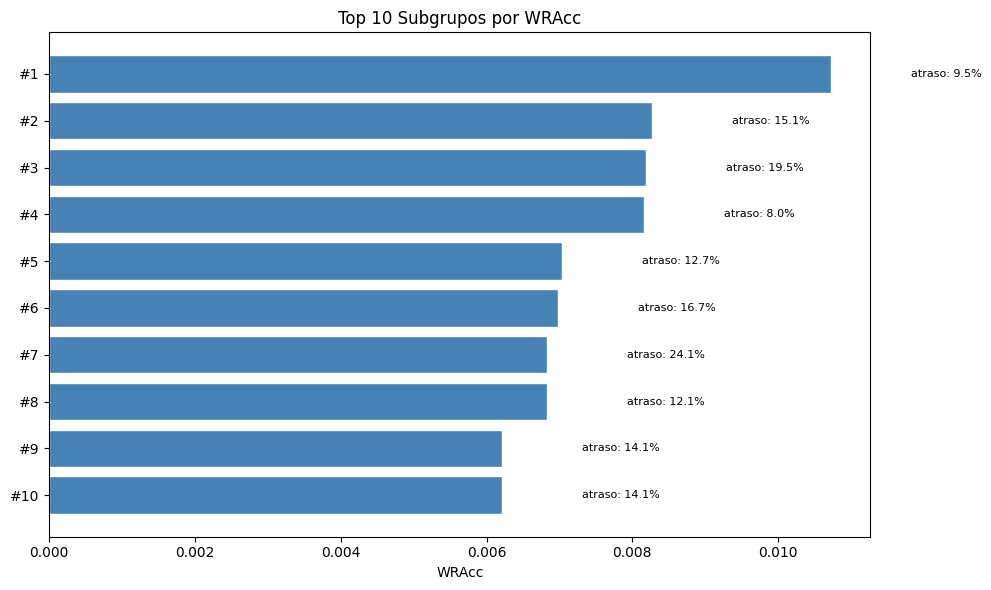

In [6]:
top10 = resultados.head(10).copy()
top10['label'] = [f'#{i+1}' for i in range(len(top10))]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['label'][::-1], top10['wracc'][::-1],
               color='steelblue', edgecolor='white')
ax.set_xlabel('WRAcc')
ax.set_title('Top 10 Subgrupos por WRAcc')

# Adicionar taxa de atraso nas barras
for bar, (_, row) in zip(bars[::-1], top10.iterrows()):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'  atraso: {row["taxa_atraso_sg"]:.1%}',
            va='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('./data/top10_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Análise detalhada dos Top 5 subgrupos

In [12]:
print('ANÁLISE DETALHADA — TOP 5 SUBGRUPOS')

for i, row in resultados.head(5).iterrows():
    print(f'\n Subgrupo #{i+1}')
    print(f'   Descrição  : {row["descricao"]}')
    print(f'   WRAcc      : {row["wracc"]:.4f}')
    print(f'   Tamanho    : {row["tamanho_sg"]:,} pedidos ({row["cobertura"]:.1%} do total)')
    print(f'   Taxa atraso: {row["taxa_atraso_sg"]:.1%} vs {row["taxa_atraso_geral"]:.1%} geral')
    print(f'   Lift       : {row["lift"]:.2f}x')
    print('-' * 70)

ANÁLISE DETALHADA — TOP 5 SUBGRUPOS

 Subgrupo #1
   Descrição  : interestadual=='interestadual' AND seller_state=='SP'
   WRAcc      : 0.0107
   Tamanho    : 37,680 pedidos (39.1% do total)
   Taxa atraso: 9.5% vs 6.8% geral
   Lift       : 1.41x
----------------------------------------------------------------------

 Subgrupo #2
   Descrição  : mes_compra=='3'
   WRAcc      : 0.0083
   Tamanho    : 9,549 pedidos (9.9% do total)
   Taxa atraso: 15.1% vs 6.8% geral
   Lift       : 2.23x
----------------------------------------------------------------------

 Subgrupo #3
   Descrição  : interestadual=='interestadual' AND mes_compra=='3'
   WRAcc      : 0.0082
   Tamanho    : 6,196 pedidos (6.4% do total)
   Taxa atraso: 19.5% vs 6.8% geral
   Lift       : 2.88x
----------------------------------------------------------------------

 Subgrupo #4
   Descrição  : interestadual=='interestadual'
   WRAcc      : 0.0082
   Tamanho    : 61,769 pedidos (64.0% do total)
   Taxa atraso: 8.0% vs 6.

### 5.4 Quais features aparecem mais nos subgrupos?

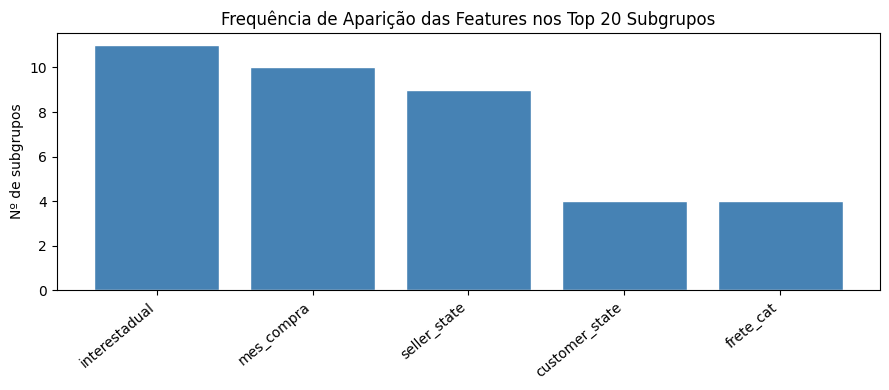

       feature  frequencia
 interestadual          11
    mes_compra          10
  seller_state           9
customer_state           4
     frete_cat           4


In [8]:
# Extrair os atributos presentes em cada descrição de subgrupo
from collections import Counter

atributos = []
for desc in resultados['descricao'].astype(str):
    for feat in feature_cols:
        if feat in desc:
            atributos.append(feat)

contagem = Counter(atributos)
freq_df = pd.DataFrame(contagem.items(), columns=['feature', 'frequencia']).sort_values(
    'frequencia', ascending=False
)

plt.figure(figsize=(9, 4))
plt.bar(freq_df['feature'], freq_df['frequencia'], color='steelblue', edgecolor='white')
plt.title('Frequência de Aparição das Features nos Top 20 Subgrupos')
plt.ylabel('Nº de subgrupos')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('./data/features_subgrupos.png', dpi=150, bbox_inches='tight')
plt.show()

print(freq_df.to_string(index=False))

### 5.5 Exportar resultados para CSV

In [10]:
resultados[cols_exibir + ['lift']].to_csv('./data/subgrupos_resultado.csv', index=False)
print('Resultados exportados: ./data/subgrupos_resultado.csv')

Resultados exportados: ./data/subgrupos_resultado.csv


---
**O que foi feito:**
- Aplicado BeamSearch com WRAcc para descoberta de subgrupos na variável "atrasado"
- Gerada tabela com os 20 melhores subgrupos e suas métricas (WRAcc, cobertura, lift, taxa de atraso)
- Analisados detalhadamente os Top 5 subgrupos
- Identificadas as features mais relevantes para explicar atrasos
- Gerados 4 gráficos prontos para uso no artigo

**Arquivos gerados em "./data/":**
- subgrupos_resultado.csv — tabela completa de resultados
- scatter_subgrupos.png — dispersão cobertura vs taxa de atraso
- top10_subgrupos.png — ranking por WRAcc
- features_subgrupos.png — frequência de features nos subgrupos